# 1. Import Libraries

In [1]:
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# 2. Load the Wine Dataset


In [2]:
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

In [3]:
print(feature_names)
print(target_names)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
['class_0' 'class_1' 'class_2']


# 3. Explore the Dataset

In [4]:
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
print(df.head())
df

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [5]:
print(df.shape)
print(df.size)  # 178*14

(178, 14)
2492


# 4. Split Data


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 5. Build and Train the Decision Tree


In [7]:
clf = DecisionTreeClassifier(
    criterion="entropy", max_depth=4, random_state=42
)
clf.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

# 6. Evaluate the Model

In [8]:
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=target_names))


Accuracy: 0.8518518518518519
Classification Report:
               precision    recall  f1-score   support

     class_0       0.82      0.95      0.88        19
     class_1       0.89      0.81      0.85        21
     class_2       0.85      0.79      0.81        14

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.86      0.85      0.85        54



# 7. Visualize the Decision Tree

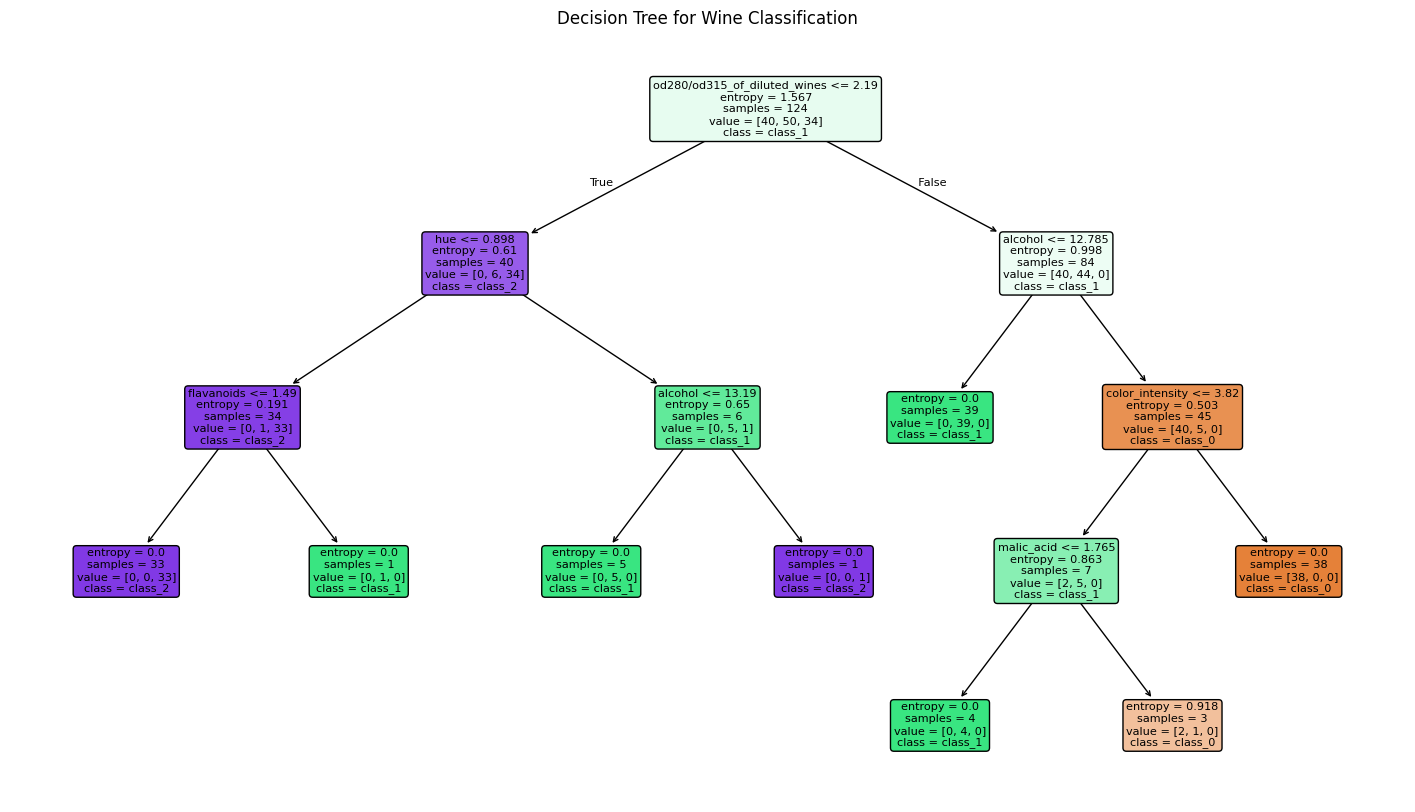

In [9]:
plt.figure(figsize=(18,10))
plot_tree(
    clf, 
    feature_names=feature_names, 
    class_names=target_names, 
    filled=True, 
    rounded=True
)
plt.title("Decision Tree for Wine Classification")
plt.show()

In [10]:
import numpy as np
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]
for f in range(X.shape[1]):
    print(f"{feature_names[indices[f]]}: {importances[indices[f]]:.3f}")

od280/od315_of_diluted_wines: 0.449
alcohol: 0.340
color_intensity: 0.087
hue: 0.073
flavanoids: 0.034
malic_acid: 0.017
proline: 0.000
proanthocyanins: 0.000
nonflavanoid_phenols: 0.000
magnesium: 0.000
total_phenols: 0.000
ash: 0.000
alcalinity_of_ash: 0.000


In [11]:
# predict the class for a new wine sample
sample = [[13.0, 2.0, 2.36, 18.6, 101.0, 2.8, 3.24, 0.3, 2.81, 5.68, 1.03, 3.17, 1185.0]]

predicted_class = clf.predict(sample)
print("Predicted class:", predicted_class)

Predicted class: [0]


In [12]:
print(wine.target_names)

['class_0' 'class_1' 'class_2']
